# Sentiment Analysis with a Bidirectional LSTM

We classify Amazon product reviews as **positive (1)** or **negative (0)** using a
**Bidirectional LSTM** that operates directly on word sequences.

Unlike the feedforward ANN which uses a TF-IDF bag-of-words representation, the
BiLSTM reads each review token-by-token in both directions, allowing it to capture
word order and local context (e.g. *"not good"* vs *"good"*).

**Pipeline overview**
```
Raw text  →  Lightweight cleaning  →  Vocabulary (train only)
          →  Integer-encoded + padded sequences
          →  Embedding layer  →  BiLSTM  →  [h_fwd ; h_bwd]  →  Linear classifier
```

## Setup & Imports

Standard scientific Python stack plus PyTorch for the neural network and a small set
of project-local helpers.

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils import (
    device_check,
    fit, evaluate, plot_confusion_matrix,
    Vocabulary, SentimentBiLSTM,
    save_bilstm_run,
)

# Suppress NumPy 2.4 VisibleDeprecationWarning triggered inside torchvision
warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

device = device_check()

PyTorch: 2.11.0+cpu | Python: 3.13.7 | OS: Windows 11
CUDA available: False
Using cpu


In [2]:
LOG_WANDB = False  # Set False to disable wandb logging
SEED      = 1

# Assumes the notebook is launched from Lab1/src.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR  = NOTEBOOK_DIR.parent
WANDB_DIR    = PROJECT_DIR
SPLITS_DIR   = PROJECT_DIR / 'data' / 'splits'
MODELS_DIR   = PROJECT_DIR / 'models'

# Make results reproducible
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

---
## Initial Test — 1 K Amazon Reviews

### Load Pre-split Data

In [3]:
train_df = pd.read_csv(SPLITS_DIR / '1k_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / '1k_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / '1k_test.csv')

def preprocess_seq(df: pd.DataFrame) -> pd.DataFrame:
    """Lightweight cleaning for sequence models.

    Unlike the TF-IDF pipeline we keep stopwords here — they carry positional
    context that the BiLSTM can exploit (e.g. 'not good' vs 'good').
    Steps: lowercase → strip email/IP addresses → remove punctuation & digits.
    """
    df = df.copy()
    s = df['Sentence'].str.lower()
    s = s.str.replace(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', '', regex=True)
    s = s.str.replace(r'(?:\d{1,3}\.){3}\d{1,3}', '', regex=True)
    s = s.str.replace(r'[^\w\s]', ' ', regex=True)
    s = s.str.replace(r'\d+', ' ', regex=True)
    s = s.str.replace(r'\s+', ' ', regex=True).str.strip()
    df['Sentence'] = s
    return df

train_df = preprocess_seq(train_df)
val_df   = preprocess_seq(val_df)
test_df  = preprocess_seq(test_df)

X_train = train_df['Sentence'].tolist()
X_val   = val_df['Sentence'].tolist()
X_test  = test_df['Sentence'].tolist()
y_train = train_df['Class'].values.astype('int64')
y_val   = val_df['Class'].values.astype('int64')
y_test  = test_df['Class'].values.astype('int64')

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Train: 810  |  Val: 90  |  Test: 100


### Vocabulary

A `Vocabulary` maps each unique token to an integer ID.
It is built **only from the training set** to avoid data leakage.

Two special tokens are always reserved:
- **Index 0 — `<PAD>`**: used to right-pad short sequences to a fixed length; the
  embedding layer ignores this index.
- **Index 1 — `<UNK>`**: assigned to any token not seen during training (out-of-vocabulary).

`min_freq=1` keeps every token from the (small) 1 K training set.

In [4]:
vocab = Vocabulary().build(X_train, min_freq=1)
print(f'Vocab size: {len(vocab):,}')

Vocabulary built — 1,582 tokens  (min_freq=1)
Vocab size: 1,582


### Tokenization & Padding

Each review is encoded to a fixed-length integer sequence:

1. **Tokenize**: split on whitespace.
2. **Truncate**: keep at most `MAX_SEQ_LEN` tokens.
3. **Pad**: right-pad shorter sequences with `<PAD>` (index 0).
4. **Map to `LongTensor`**: the embedding layer expects integer (not float) inputs.

We choose `MAX_SEQ_LEN = 128`, which covers the vast majority of reviews without
excessive padding overhead.

In [5]:
MAX_SEQ_LEN = 128

def encode_corpus(texts, vocab, max_len):
    return torch.tensor(
        [vocab.encode(t, max_len) for t in texts],
        dtype=torch.long,
    )

X_train_t = encode_corpus(X_train, vocab, MAX_SEQ_LEN)
X_val_t   = encode_corpus(X_val,   vocab, MAX_SEQ_LEN)
X_test_t  = encode_corpus(X_test,  vocab, MAX_SEQ_LEN)

y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)
y_test_t  = torch.from_numpy(y_test)

# Sanity check: show sequence lengths before padding
lengths = [len(t.split()) for t in X_train]
print(f'Sequence lengths — min: {min(lengths)}  median: {int(np.median(lengths))}  '
      f'max: {max(lengths)}  (cap: {MAX_SEQ_LEN})')

Sequence lengths — min: 1  median: 9  max: 31  (cap: 128)


### DataLoaders

The encoded tensors are wrapped in `TensorDataset` objects and handed off to
PyTorch `DataLoader`s for batching and (training) shuffling.

In [6]:
BATCH_SIZE = 64

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

### Model Architecture

A bidirectional LSTM with a linear classification head.

```
Input (seq_len)  →  Embedding(vocab_size, 64)  →  Dropout(0.3)
                 →  BiLSTM(64→128, 1 layer)
                 →  concat [h_fwd ; h_bwd]  →  (256,)
                 →  Dropout(0.3)  →  Linear(256, 2)
```

**Why bidirectional?**  
A standard LSTM only sees left context at each time step. The backward pass gives
right context too, so the final representation captures the full sentence from
both ends — useful for sentiment where the end of a review often contradicts the
beginning (*"... but overall terrible"*).

In [7]:
EMBED_DIM  = 64
HIDDEN_DIM = 128
NUM_LAYERS = 1
DROPOUT    = 0.3

model = SentimentBiLSTM(
    vocab_size  = len(vocab),
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_classes = 2,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')


Trainable parameters: 300,418


### Training

The model is trained with **Adam** and **cross-entropy loss** for up to 100 epochs.
Early stopping with `patience=10` halts training if validation loss does not improve
for 10 consecutive epochs. The best-validation-loss checkpoint is restored at the end.

In [8]:
NUM_EPOCHS    = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
OUT_DIR       = MODELS_DIR / 'bilstm_1k'

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity="d7047e-group12",
    project="Lab1",
    name="BiLSTM 1K",
    tags=["Task 1.2", "BiLSTM", "1K"],
    dir=WANDB_DIR,
    config={
        "dataset":     "Amazon 1K",
        "optimizer":   type(optimizer).__name__,
        "embed_dim":   EMBED_DIM,
        "hidden_dim":  HIDDEN_DIM,
        "num_layers":  NUM_LAYERS,
        "dropout":     DROPOUT,
        "lr":          LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "epochs":      NUM_EPOCHS,
        "batch_size":  BATCH_SIZE,
        "max_seq_len": MAX_SEQ_LEN,
        "vocab_size":  len(vocab),
    },
    mode='online' if LOG_WANDB else 'disabled',
)

_ = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    patience=10,
)

_ = save_bilstm_run(
    out_dir     = OUT_DIR,
    model       = model,
    vocab       = vocab,
    max_seq_len = MAX_SEQ_LEN,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    num_classes = 2,
    dropout     = DROPOUT,
)

Epoch   | Train Loss | Train Acc  | Val Loss   | Val Acc   
  1/100 | 0.6857     | 54.81    % | 0.6839     | 51.11    %
  2/100 | 0.6510     | 67.65    % | 0.6653     | 52.22    %
  3/100 | 0.6007     | 70.00    % | 0.6452     | 57.78    %
  4/100 | 0.5526     | 73.58    % | 0.6245     | 61.11    %
  5/100 | 0.5174     | 73.58    % | 0.6104     | 63.33    %
 10/100 | 0.3401     | 86.05    % | 0.6363     | 67.78    %
 15/100 | 0.2288     | 90.74    % | 0.4950     | 74.44    %
 20/100 | 0.1421     | 94.57    % | 0.5260     | 76.67    %
 25/100 | 0.0795     | 98.02    % | 0.5477     | 74.44    %
 30/100 | 0.0626     | 98.15    % | 0.7354     | 71.11    %
 34/100 | 0.0853     | 97.04    % | 0.6844     | 72.22    %

Early stopping triggered at epoch 34 (no improvement for 10 epochs)

Restored best weights (val loss 0.4910)

BiLSTM run saved to: c:\Users\Oscar\Projects\D7047E\Lab1\models\bilstm_1k


### Evaluation on the Test Set

The saved best checkpoint is run on the held-out test set.
`evaluate` reports overall accuracy and a per-class precision/recall/F1 breakdown.

In [9]:
_ = evaluate(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    label='BiLSTM — 1K Samples',
    class_names=['Negative', 'Positive'],
)

Classification Report: BiLSTM — 1K Samples

              precision    recall  f1-score   support

    Negative      0.702     0.800     0.748        50
    Positive      0.767     0.660     0.710        50

    accuracy                          0.730       100
   macro avg      0.735     0.730     0.729       100
weighted avg      0.735     0.730     0.729       100



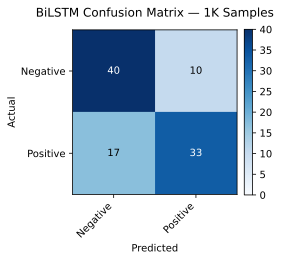

In [10]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=2,
    class_names=['Negative', 'Positive'],
    title='BiLSTM Confusion Matrix — 1K Samples',
)